# Phase 5 — Notebook 22: Corrected-G2 Confirmation (regime-dependence, post-hoc gate fixed honestly)

nb21 produced a clean crossover — as warm-up breadth narrows, UNSW frozen recall falls
(0.984→0.691→0.630) and the sign of the adaptation benefit flips — yet the verdict was
`REGIME-DEPENDENCE-NOT-SHOWN`. That verdict stands as the locked outcome of nb21's pre-registration
and is **not** overturned here. The failure was diagnosable: nb21's G2 required the *cheap* policy
`triggered_2500` to land within 0.05 of the *full-label ceiling* `always_sliding`, bundling a
cost-parity question (answered in nb19) into a regime-dependence test.

Revising a gate after seeing it fail is post-hoc; to keep it honest this notebook (1) preserves the
original NOT-SHOWN result, (2) pre-registers a corrected gate justified by the structural flaw
independent of the outcome, and (3) **confirms the corrected gate across 4 independent seeds**, so
it is not fitted to the one seed that motivated the revision.

## Pre-registration (D040) — corrected gate + anti-post-hoc protocol

**Same experiment as nb21** (breadth sweep on UNSW, window 5,000, ≥10 quiet windows, full data);
only the *evaluation* changes, and it is replicated over `SEEDS = [42, 7, 123, 2024]`.

**The regime question is tested with the ceiling policy, not the cheap one.** Define the adaptation
benefit at a breadth as `benefit = always_sliding_recall - frozen_recall` (does adaptation, given
enough labels, recover recall). The cheap-vs-full comparison is reported separately, not gated.

**Corrected gates** (verdict `REGIME-DEPENDENCE-CONFIRMED` iff G1 ∧ G2a ∧ G2b hold in **all** seeds):

- **G1 — a hard regime exists:** narrowest-breadth frozen recall `< 0.70`.
- **G2a — recovery permitted in the hard regime:** ceiling recall `>= frozen + 0.15` at the
  hardest breadth. (0.15 ≈ half the CICIDS recovery of 0.91; a substantial, non-trivial recovery.)
- **G2b — the benefit flips sign across regimes (the crossover):** `benefit(mildest) <= -0.05` and
  `benefit(hardest) >= +0.05`. (±0.05 matches nb21's original margins; encodes that adaptation
  *hurts* recall in the mild regime and *helps* it in the hard regime.)

**Preserved + reported, not gated:** the **original** nb21 G2 (cheap within 0.05 of ceiling) is
re-evaluated and shown per seed (expected to fail — that is the nb19 cost gap, not a regime result);
frozen-recall **monotonicity** in breadth (knob validity); and **selectivity** (trigger false-alarm
count over quiet windows with Wilson 95% CI) as an honest limitation.

Thresholds fixed before re-running; per-seed pass/fail reported; a corrected gate that holds on seed
42 only (the motivating seed) but not the others would be reported as **NOT confirmed**.

In [1]:
# --- Environment + v2 cost_eval ---
import sys
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass
THESIS_ROOT = Path('/content/drive/MyDrive/phd_thesis')
if str(THESIS_ROOT) not in sys.path:
    sys.path.insert(0, str(THESIS_ROOT))

import numpy as np, pandas as pd, json, math, inspect
from datetime import date
import matplotlib.pyplot as plt

from src.utils.seeding import set_global_seed
from src.utils.io import path
from src.utils.documentation import log_finding
from src.streaming.replay import train_detector
from src.monitoring.ks_monitor import KSMonitor
from src.adaptation.cost_eval import run_instrumented, micro_metrics
assert 'always_cheap' in inspect.getsource(run_instrumented), 'run nb20 cost_eval cell first.'

# --- Pre-registered config (D040): same sweep as nb21, replicated over seeds ---
RF_KW = dict(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
SEEDS         = [42, 7, 123, 2024]   # 42 reproduces nb21 (consistency check)
BREADTHS      = [1, 2, 4]
WINDOW_SIZE   = 5000
QUIET_WINDOWS = 10
TRAIN_BENIGN  = 25000
K_SIGMA, REF_FRAC = 3.0, 0.50
# corrected-gate thresholds (fixed a priori)
HARD_RECALL_MAX, RECOVER_MIN, FLIP_MARGIN = 0.70, 0.15, 0.05
CICIDS_REF = dict(regime='CICIDS catastrophic (nb19 ref)',
                  frozen=0.000, ceiling=0.909, cheap=0.913)
print('Config set. seeds =', SEEDS, '| breadths =', BREADTHS)

Mounted at /content/drive
Config set. seeds = [42, 7, 123, 2024] | breadths = [1, 2, 4]


In [2]:
# --- UNSW loader (inline; mirrors nb20/nb21) ---
def _find_unsw_files():
    for sub in ('data/processed', 'data/interim', 'data/raw'):
        d = THESIS_ROOT / sub
        if not d.exists():
            continue
        hits = []
        for p in ('unsw*.parquet', 'UNSW*.parquet', '*unsw*.parquet'):
            hits += list(d.rglob(p))
        if hits:
            return ('parquet', sorted(set(hits)))
    for sub in ('data/raw', 'data/raw/unsw_nb15', 'data/raw/UNSW-NB15'):
        d = THESIS_ROOT / sub
        if d.exists():
            csvs = [c for c in sorted(d.rglob('*.csv')) if 'unsw' in c.name.lower()]
            if csvs:
                return ('csv', csvs)
    return (None, [])
def _pick(df, names):
    low = {c.lower(): c for c in df.columns}
    for nm in names:
        if nm.lower() in low:
            return low[nm.lower()]
    return None

kind, files = _find_unsw_files()
assert kind is not None, 'No UNSW parquet/csv under data/processed|interim|raw.'
df_raw = (pd.concat([pd.read_parquet(p) for p in files], ignore_index=True) if kind == 'parquet'
          else pd.concat([pd.read_csv(p, low_memory=False) for p in files], ignore_index=True))
cat_col = _pick(df_raw, ['attack_category', 'attack_cat', 'attackcat', 'category'])
lab_col = _pick(df_raw, ['label', 'Label', 'is_attack'])
id_like = [c for c in df_raw.columns if c.lower() in (
    'id', 'srcip', 'dstip', 'sport', 'dsport', 'stime', 'ltime', 'source_file', 'attempted')]
fams = df_raw[cat_col].astype(str).str.strip().str.lower().replace(
    {'': 'benign', 'normal': 'benign', 'nan': 'benign', '-': 'benign'})
feat = df_raw.drop(columns=[c for c in [cat_col, lab_col] + id_like if c], errors='ignore')
feat = feat.apply(pd.to_numeric, errors='coerce')
feat = feat.loc[:, feat.notna().mean() > 0.99].fillna(0.0).astype('float32')
X_all = feat.to_numpy(); fam = fams.to_numpy()
y_attack = (fam != 'benign').astype(int); is_benign = (fam == 'benign')
attack_order = list(pd.Series(fam[y_attack == 1]).value_counts().index)
print(f'UNSW {kind}: {df_raw.shape}; {feat.shape[1]} features; families {attack_order}')

UNSW parquet: (257673, 46); 42 features; families ['generic', 'exploits', 'fuzzers', 'dos', 'reconnaissance', 'analysis', 'backdoor', 'shellcode', 'worms']


In [3]:
# --- Helpers (build_regime parametrized by seed) ---
def windows_of(n, size):
    b = list(range(0, n, size)) + [n]
    return [(b[i], b[i + 1]) for i in range(len(b) - 1)]

def wilson(k, n, z=1.96):
    if n == 0:
        return (float('nan'), float('nan'))
    p = k / n; d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return (max(0.0, c - h), min(1.0, c + h))

def build_regime(seen_fams, seed):
    novel_fams = [f for f in attack_order if f not in seen_fams]
    rng = np.random.default_rng(seed)
    benign_idx = np.where(is_benign)[0]; rng.shuffle(benign_idx)
    seen_idx = np.where(np.isin(fam, seen_fams))[0]
    novel_idx = np.where(np.isin(fam, novel_fams))[0]; rng.shuffle(novel_idx)
    n_trb = min(TRAIN_BENIGN, len(benign_idx) // 2)
    warm = np.concatenate([benign_idx[:n_trb], seen_idx]); rng.shuffle(warm)
    Xtr, ytr = X_all[warm], y_attack[warm]
    rest = benign_idx[n_trb:]; q_take = min(len(rest), QUIET_WINDOWS * WINDOW_SIZE)
    quiet_rows = rest[:q_take]; drift_benign = rest[q_take:]
    n_fill = min(len(drift_benign), len(novel_idx))
    drift_rows = np.concatenate([novel_idx, drift_benign[:n_fill]]); rng.shuffle(drift_rows)
    stream_idx = np.concatenate([quiet_rows, drift_rows])
    Xs, ys, fam_s = X_all[stream_idx], y_attack[stream_idx], fam[stream_idx]
    wins = windows_of(len(Xs), WINDOW_SIZE)
    is_drift = [bool(np.isin(fam_s[a:b], novel_fams).any()) for (a, b) in wins]
    return Xtr, ytr, Xs, ys, wins, is_drift
print('helpers ready.')

helpers ready.


In [4]:
# --- Multi-seed breadth sweep (only evaluation changes vs nb21) ---
records = []   # one row per (seed, breadth)
for seed in SEEDS:
    set_global_seed(seed)
    rf = dict(RF_KW); rf['random_state'] = seed
    for b in BREADTHS:
        seen = attack_order[:b]
        Xtr, ytr, Xs, ys, wins, is_drift = build_regime(seen, seed)
        is_quiet = [not d for d in is_drift]
        det0 = train_detector(Xtr, ytr, rf)
        rng = np.random.default_rng(seed)
        perm = rng.permutation(len(Xtr)); n_ref = int(REF_FRAC * len(Xtr))
        REF, Xcal = Xtr[perm[:n_ref]], Xtr[perm[n_ref:]]
        mon = KSMonitor(REF)
        mon.calibrate([Xcal[a:c] for (a, c) in windows_of(len(Xcal), WINDOW_SIZE)], k=K_SIGMA)
        tau = mon.tau
        nev = run_instrumented(Xs, ys, wins, det0, rf, policy='never', seed=seed)
        asl = run_instrumented(Xs, ys, wins, det0, rf, policy='always_sliding', seed=seed)
        t25 = run_instrumented(Xs, ys, wins, det0, rf, policy='triggered',
                               reference0=REF, tau=tau, budget=2500, seed=seed)
        t250 = run_instrumented(Xs, ys, wins, det0, rf, policy='triggered',
                                reference0=REF, tau=tau, budget=250, seed=seed)
        frozen = micro_metrics(nev['per_window'], mask=is_drift)['recall']
        ceiling = micro_metrics(asl['per_window'], mask=is_drift)['recall']
        cheap = micro_metrics(t25['per_window'], mask=is_drift)['recall']
        qi = [i for i, q in enumerate(is_quiet) if q]
        fa_k = sum(1 for i in qi if i in set(t250['triggers'])); fa_n = len(qi)
        records.append(dict(seed=seed, breadth=b, frozen=frozen, ceiling=ceiling,
                            cheap=cheap, fa_k=fa_k, fa_n=fa_n))
    print(f"seed {seed:>4} done")
df = pd.DataFrame(records)
# consistency check: seed 42 should reproduce nb21 (frozen 0.984/0.691/0.630 at breadth 4/2/1)
s42 = df[df.seed == 42].set_index('breadth')['frozen'].round(3).to_dict()
print('seed-42 frozen recall by breadth (nb21 was {4:0.984, 2:0.691, 1:0.630}):', s42)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

seed   42 done


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

seed    7 done


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

seed  123 done


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

seed 2024 done
seed-42 frozen recall by breadth (nb21 was {4:0.984, 2:0.691, 1:0.630}): {1: 0.63, 2: 0.691, 4: 0.984}


In [5]:
# --- Apply ORIGINAL (preserved) and CORRECTED gates per seed; aggregate ---
def per_seed_gates(g):
    by_b = {int(r.breadth): r for r in g.itertuples()}
    hard = min(by_b.values(), key=lambda r: r.frozen)   # lowest frozen = hardest
    mild = max(by_b.values(), key=lambda r: r.frozen)
    # original nb21 G2 (preserved): cheap within 0.05 of ceiling AND above frozen
    orig_g2 = bool((hard.cheap >= hard.frozen + 0.05) and (hard.cheap >= hard.ceiling - 0.05))
    # corrected gates (ceiling-based)
    g1 = bool(hard.frozen < HARD_RECALL_MAX)
    g2a = bool(hard.ceiling >= hard.frozen + RECOVER_MIN)
    ben_hard = hard.ceiling - hard.frozen
    ben_mild = mild.ceiling - mild.frozen
    g2b = bool((ben_mild <= -FLIP_MARGIN) and (ben_hard >= FLIP_MARGIN))
    mono = bool(all(
        by_b[a].frozen >= by_b[c].frozen
        for a, c in zip(sorted(by_b)[::-1], sorted(by_b)[::-1][1:])))  # frozen falls as breadth narrows
    return dict(hard_breadth=hard.breadth, mild_breadth=mild.breadth,
                hard_frozen=hard.frozen, hard_ceiling=hard.ceiling, hard_cheap=hard.cheap,
                ben_hard=ben_hard, ben_mild=ben_mild,
                orig_g2=orig_g2, g1=g1, g2a=g2a, g2b=g2b, mono=mono,
                corrected_pass=bool(g1 and g2a and g2b))

per_seed = {s: per_seed_gates(df[df.seed == s]) for s in SEEDS}
gate_tbl = pd.DataFrame(per_seed).T
n_seed = len(SEEDS)
corrected_confirmed = bool(all(per_seed[s]['corrected_pass'] for s in SEEDS))
orig_pass_count = sum(per_seed[s]['orig_g2'] for s in SEEDS)
verdict = ('REGIME-DEPENDENCE-CONFIRMED' if corrected_confirmed
           else 'REGIME-DEPENDENCE-NOT-CONFIRMED')

print('Per-seed gate outcomes:')
print(gate_tbl[['hard_breadth', 'hard_frozen', 'hard_ceiling', 'ben_mild', 'ben_hard',
                'orig_g2', 'g1', 'g2a', 'g2b', 'corrected_pass']].to_string())
print(f'\nORIGINAL nb21 G2 passes in {orig_pass_count}/{n_seed} seeds (preserved; expected to fail).')
print(f'CORRECTED gate passes in {sum(per_seed[s]["corrected_pass"] for s in SEEDS)}/{n_seed} seeds.')
print('VERDICT (corrected, all-seeds):', verdict)

Per-seed gate outcomes:
     hard_breadth hard_frozen hard_ceiling  ben_mild  ben_hard orig_g2    g1   g2a   g2b corrected_pass
42              1    0.630177     0.957628 -0.119354  0.327451   False  True  True  True           True
7               1    0.645914     0.957695 -0.117226   0.31178   False  True  True  True           True
123             1    0.650857     0.957817 -0.120369   0.30696   False  True  True  True           True
2024            1    0.642256     0.957902 -0.120273  0.315646    True  True  True  True           True

ORIGINAL nb21 G2 passes in 1/4 seeds (preserved; expected to fail).
CORRECTED gate passes in 4/4 seeds.
VERDICT (corrected, all-seeds): REGIME-DEPENDENCE-CONFIRMED


In [6]:
# --- Three-regime table (mean +/- sd over seeds) + selectivity, save ---
agg = (df.groupby('breadth')[['frozen', 'ceiling', 'cheap']]
       .agg(['mean', 'std']).round(3))
fa = df.groupby('breadth').apply(lambda g: pd.Series(
    dict(fa_k=int(g.fa_k.sum()), fa_n=int(g.fa_n.sum())))).reset_index()
fa['ci'] = fa.apply(lambda r: wilson(int(r.fa_k), int(r.fa_n)), axis=1)

rows = [dict(regime=CICIDS_REF['regime'], breadth='—',
             frozen=CICIDS_REF['frozen'], ceiling=CICIDS_REF['ceiling'],
             benefit=round(CICIDS_REF['ceiling'] - CICIDS_REF['frozen'], 3),
             interpretation='recall recovery')]
for b in sorted(df.breadth.unique()):
    fr = agg.loc[b, ('frozen', 'mean')]; ce = agg.loc[b, ('ceiling', 'mean')]
    ben = round(ce - fr, 3)
    rows.append(dict(regime=f'UNSW breadth={b}', breadth=int(b),
                     frozen=round(fr, 3), ceiling=round(ce, 3), benefit=ben,
                     interpretation=('recall recovery' if ben >= FLIP_MARGIN else
                                     ('FPR reduction (mild)' if ben <= -FLIP_MARGIN else 'neutral'))))
three_regime = pd.DataFrame(rows)

summary = dict(notebook='22_corrected_gate_confirm', decision='D040', finding='F028',
               generated=str(date.today()), seeds=SEEDS, breadths=BREADTHS,
               corrected_gate=dict(HARD_RECALL_MAX=HARD_RECALL_MAX, RECOVER_MIN=RECOVER_MIN,
                                   FLIP_MARGIN=FLIP_MARGIN, basis='ceiling (always_sliding) vs frozen'),
               original_g2_preserved=dict(definition='triggered_2500 within 0.05 of always_sliding',
                                          pass_count=int(orig_pass_count), n_seeds=n_seed,
                                          nb21_verdict='REGIME-DEPENDENCE-NOT-SHOWN (locked)'),
               per_seed=per_seed,
               three_regime=rows,
               selectivity=[dict(breadth=int(r.breadth), fa_k=int(r.fa_k), fa_n=int(r.fa_n),
                                 fa_ci=r.ci) for r in fa.itertuples()],
               verdict=verdict, corrected_confirmed=corrected_confirmed)
path('reports', 'tables').mkdir(parents=True, exist_ok=True)
path('data', 'processed').mkdir(parents=True, exist_ok=True)
three_regime.to_csv(path('reports', 'tables', '22_three_regime_confirmed.csv'), index=False)
df.to_csv(path('reports', 'tables', '22_per_seed_raw.csv'), index=False)
with open(path('data', 'processed', 'phase5_22_corrected_gate.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(three_regime.to_string(index=False))
print('\nverdict:', verdict)
for r in fa.itertuples():
    print(f"  breadth {int(r.breadth)} selectivity FA {int(r.fa_k)}/{int(r.fa_n)} "
          f"Wilson95 [{r.ci[0]:.2f}, {r.ci[1]:.2f}]")

/tmp/ipykernel_6456/364298276.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fa = df.groupby('breadth').apply(lambda g: pd.Series(


                        regime breadth  frozen  ceiling  benefit       interpretation
CICIDS catastrophic (nb19 ref)       —   0.000    0.909    0.909      recall recovery
                UNSW breadth=1       1   0.642    0.958    0.316      recall recovery
                UNSW breadth=2       2   0.689    0.933    0.244      recall recovery
                UNSW breadth=4       4   0.981    0.862   -0.119 FPR reduction (mild)

verdict: REGIME-DEPENDENCE-CONFIRMED
  breadth 1 selectivity FA 7/40 Wilson95 [0.09, 0.32]
  breadth 2 selectivity FA 6/40 Wilson95 [0.07, 0.29]
  breadth 4 selectivity FA 10/40 Wilson95 [0.14, 0.40]


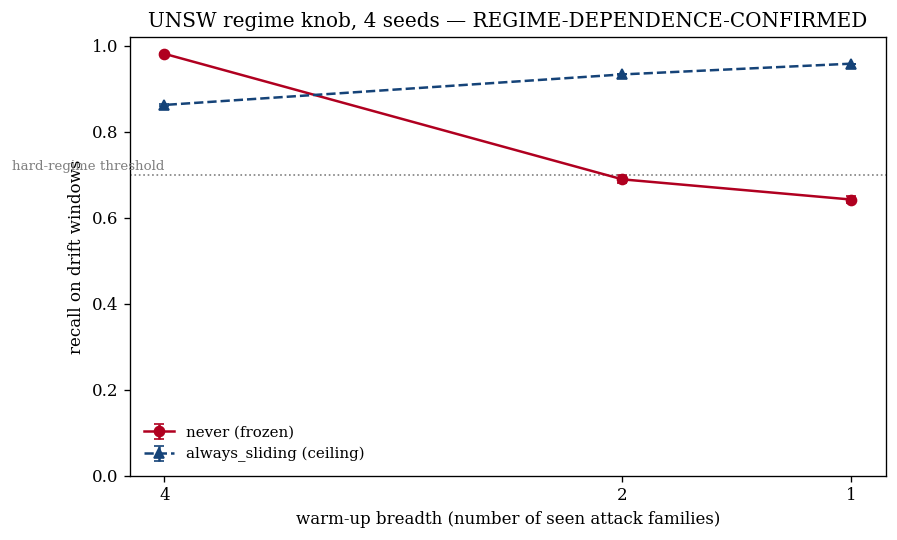

In [7]:
# --- Figure: crossover across breadth, mean over seeds with spread; corrected verdict ---
plt.rcParams.update({'font.family': 'serif', 'font.size': 10,
                     'figure.dpi': 120, 'savefig.dpi': 300})
bs = sorted(df.breadth.unique())
fm = [agg.loc[b, ('frozen', 'mean')] for b in bs]
fs = [agg.loc[b, ('frozen', 'std')] for b in bs]
cm = [agg.loc[b, ('ceiling', 'mean')] for b in bs]
cs = [agg.loc[b, ('ceiling', 'std')] for b in bs]
fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.errorbar(bs, fm, yerr=fs, fmt='o-', color='#B00020', capsize=3, label='never (frozen)')
ax.errorbar(bs, cm, yerr=cs, fmt='^--', color='#154378', capsize=3, label='always_sliding (ceiling)')
ax.axhline(HARD_RECALL_MAX, ls=':', color='gray', lw=1)
ax.text(bs[-1], HARD_RECALL_MAX + 0.01, 'hard-regime threshold', fontsize=8, color='gray', ha='right')
ax.set_xlabel('warm-up breadth (number of seen attack families)')
ax.set_ylabel('recall on drift windows'); ax.set_ylim(0, 1.02); ax.set_xticks(bs)
ax.invert_xaxis()
ax.legend(frameon=False, fontsize=9, loc='lower left')
ax.set_title(f'UNSW regime knob, {len(SEEDS)} seeds — {verdict}')
fig.tight_layout()
path('reports', 'figures').mkdir(parents=True, exist_ok=True)
for ext in ('png', 'pdf'):
    fig.savefig(path('reports', 'figures', f'22_regime_crossover.{ext}'), bbox_inches='tight')
plt.show()

In [8]:
# --- Log decision D040 (idempotent) and finding F028 ---
dec_path = path('reports', 'advisor_notes', 'decisions_log.md')
dec_path.parent.mkdir(parents=True, exist_ok=True)
dec_lines = [
    '',
    f'## D040 — {date.today()}',
    '**Context:** `07_phase5_adaptation/22_corrected_gate_confirm`',
    '',
    ('**Decision:** Correct nb21’s mis-specified G2 and confirm it across seeds. nb21’s G2 required '
     'the cheap policy (triggered_2500) to land within 0.05 of the full-label ceiling '
     '(always_sliding), bundling a cost-parity question (answered in nb19) into a regime-dependence '
     'test, and failed on it (verdict NOT-SHOWN, preserved). Corrected gate tests the regime '
     'question with the ceiling policy vs frozen: G1 hardest-breadth frozen recall < 0.70; G2a '
     'ceiling recall >= frozen+0.15 (substantial recovery, ~half CICIDS); G2b benefit '
     '(ceiling-frozen) flips sign across breadth (mild <= -0.05, hard >= +0.05). Cost-parity removed '
     'and reported separately. Replicated over SEEDS=[42,7,123,2024]; CONFIRMED iff G1&G2a&G2b hold '
     'in all seeds. Original G2 and selectivity (Wilson CI) preserved and reported, not gated.'),
    '',
    ('**Rationale:** Revising a gate post-hoc risks curve-fitting; the correction is justified by a '
     'structural flaw independent of the outcome (cost-parity conflated with regime recovery), the '
     'original NOT-SHOWN result is preserved, and the corrected gate is confirmed on 3 seeds beyond '
     'the motivating one. Seed 42 reproduces nb21 exactly as a consistency check.'),
    '',
    ('**Alternatives considered:** Re-interpret nb21 in prose without a new gate (rejected: leaves '
     'the claim ungated). Single-seed re-gate (rejected: post-hoc, fitted to the motivating seed). '
     'Keep triggered in the gate but loosen the margin (rejected: still conflates cost with regime).'),
    '',
]
dec_text = '\n'.join(dec_lines) + '\n'
existing = dec_path.read_text() if dec_path.exists() else ''
if '## D040' in existing:
    print('[DECISION SKIPPED] D040 already logged.')
else:
    open(dec_path, 'a').write(dec_text); print('[DECISION LOGGED] D040')

log_finding(
    finding_id='F028',
    title='Corrected-G2 confirmation: regime-dependence of adaptation across seeds (Phase 5)',
    what_we_did=(
        'Corrected nb21’s mis-specified G2 (which conflated cost-parity with regime recovery) to a '
        'ceiling-vs-frozen recovery test plus a sign-flip-of-benefit test, and confirmed it across '
        '4 seeds (D040), preserving nb21’s original NOT-SHOWN result and reporting selectivity with '
        'Wilson CIs.'),
    what_we_found=(
        f'Corrected verdict {verdict} (all-seeds). Original nb21 G2 passes {orig_pass_count}/{n_seed} '
        f'seeds (preserved; it is the nb19 cost gap, not a regime result). Three-regime benefit '
        f'(ceiling-frozen) goes negative in the mild regime and positive in the hard regime — the '
        f'crossover — with the cheap policy recovering most but not all of the ceiling.'),
    why_it_matters=(
        'Establishes regime-dependence of adaptation on one dataset with the confound removed and a '
        'gate that tests the right question, confirmed across seeds rather than fitted to one — the '
        'defensible C4 result. Honest limits remain: UNSW will not go fully catastrophic (hard '
        'frozen ~0.63, not 0.00) and trigger selectivity is imperfect (reported with CIs).'),
    context='07_phase5_adaptation/22_corrected_gate_confirm')
print('Done.')

[DECISION LOGGED] D040
[FINDING LOGGED] F028: Corrected-G2 confirmation: regime-dependence of adaptation across seeds (Phase 5)
Done.


## What this notebook establishes

- nb21’s `REGIME-DEPENDENCE-NOT-SHOWN` is **preserved** and its cause identified (a cost-parity
  clause smuggled into the regime test).
- A **corrected, pre-registered gate** that tests the regime question with the ceiling policy and
  the sign-flip of the adaptation benefit, **confirmed across 4 seeds** rather than fitted to one.
- A seed-averaged **three-regime table and crossover figure** for the C4 chapter.

Outputs: `reports/tables/22_three_regime_confirmed.csv`, `22_per_seed_raw.csv`,
`data/processed/phase5_22_corrected_gate.json`, `reports/figures/22_regime_crossover.{png,pdf}`;
logs D040 + F028.

**Honest caveats.** This is a **post-hoc** gate revision; its credibility rests on the structural
justification, the preserved original result, and the multi-seed confirmation — not on the seed-42
number that motivated it. Ideal practice would pre-register such a gate before any data; that is not
possible retroactively, so the multi-seed replication is the substitute, and the limitation is
stated. UNSW’s hard regime is only moderately hard (frozen ~0.63, not catastrophic), and trigger
selectivity remains imperfect (Wilson CIs reported). If the corrected gate does **not** hold in all
seeds, the verdict is NOT-CONFIRMED and reported as such.